# 01PAO25-26 - Python, Data Types

![Instituto Superior Tecnológico Quito](img/Recurso-26.png)

**Nombre:** Germán Del Río  
**Fecha:**  06/10/2025


---


![Python Logo](img/python_logo.png)

Ejercicio_CNN

<a href="https://github.com/Saquis/MachineLearning2.git ">Enlace al Repositorio</a>

In [8]:
!pip install tensorflow 
!pip install scikit-image


   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ------------------ --------------------- 6.0/12.9 MB 36.0 MB/s eta 0:00:01
   ---------------------------------------- 12.9/12.9 MB 35.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 28.3 MB/s eta 0:00:00

   ---------------------------------------- 0/5 [tifffile]
   ---------------------------------------- 0/5 [tifffile]
   ---------------------------------------- 0/5 [tifffile]
   ---------------------------------------- 0/5 [tifffile]
   ---------------------------------------- 0/5 [tifffile]
   -------- ------------------------------- 1/5 [networkx]
   -------- ------------------------------- 1/5 [networkx]
   -------- ------------------------------- 1/5 [networkx]
   -------- ------------------------------- 1/5 [networkx]
   -------- ------------------------------- 1/5 [networkx]
   -------- ------------------------

In [50]:
# ==================================================
# 1. IMPORTACIÓN DE LIBRERÍAS NECESARIAS
# ==================================================
import numpy as np
import os
import re
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import keras
from keras.utils import to_categorical
from keras.models import Sequential, Model
from keras.layers import Input
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import BatchNormalization
from keras.layers import LeakyReLU
from keras import optimizers

In [55]:
# ==================================================
# 2. CARGA DE IMÁGENES DESDE DIRECTORIOS
# ==================================================
from skimage.transform import resize

dirname = os.path.join(os.getcwd(), 'sportimages')
imgpath = dirname + os.sep

images = []
directories = []
dircount = []
prevRoot = ''
cant = 0

# Definir tamaño estándar para todas las imágenes
IMG_HEIGHT = 21
IMG_WIDTH = 28

print("leyendo imagenes de ", imgpath)
for root, dirnames, filenames in os.walk(imgpath):
    for filename in filenames:
        if re.search(r"\.(jpg|jpeg|png|bmp|tiff)$", filename):
            cant = cant + 1
            filepath = os.path.join(root, filename)
            image = plt.imread(filepath)
            
            # Redimensionar la imagen a tamaño estándar
            if len(image.shape) == 2:  # Si es escala de grises
                image = np.stack([image]*3, axis=-1)  # Convertir a RGB
            elif image.shape[2] == 4:  # Si tiene canal alpha (RGBA)
                image = image[:, :, :3]  # Quitar canal alpha
            
            image_resized = resize(image, (IMG_HEIGHT, IMG_WIDTH, 3), 
                                   anti_aliasing=True, preserve_range=True)
            images.append(image_resized.astype(np.uint8))
            
            b = "Leyendo..." + str(cant)
            print(b, end="\r")
            if prevRoot != root:
                print(root, cant)
                prevRoot = root
                directories.append(root)
                dircount.append(cant)
                cant = 0

dircount.append(cant)
dircount = dircount[1:]
dircount[0] = dircount[0] + 1

print('Directorios leidos:', len(directories))
print("Imagenes en cada directorio", dircount)
print('suma Total de imagenes en subdirs:', sum(dircount))

leyendo imagenes de  C:\Users\RYZEN 5 GAMER\MachineLearning2\sportimages\
C:\Users\RYZEN 5 GAMER\MachineLearning2\sportimages\americano 1 1
C:\Users\RYZEN 5 GAMER\MachineLearning2\sportimages\basket 1 1
C:\Users\RYZEN 5 GAMER\MachineLearning2\sportimages\beisball 1 1
C:\Users\RYZEN 5 GAMER\MachineLearning2\sportimages\boxeo 1 1
C:\Users\RYZEN 5 GAMER\MachineLearning2\sportimages\ciclismo 1 1
C:\Users\RYZEN 5 GAMER\MachineLearning2\sportimages\f1 1 1
C:\Users\RYZEN 5 GAMER\MachineLearning2\sportimages\futbol 1 1
C:\Users\RYZEN 5 GAMER\MachineLearning2\sportimages\golf 1 1
C:\Users\RYZEN 5 GAMER\MachineLearning2\sportimages\natacion 1 1
C:\Users\RYZEN 5 GAMER\MachineLearning2\sportimages\tenis 1 1
Directorios leidos: 10
Imagenes en cada directorio [2, 1, 1, 1, 1, 1, 1, 1, 1, 0]
suma Total de imagenes en subdirs: 10


In [56]:
# ==================================================
# 3. CREACIÓN DE ETIQUETAS Y NOMBRES DE CLASES
# ==================================================
labels = []
indice = 0
for cantidad in dircount:
    for i in range(cantidad):
        labels.append(indice)
    indice = indice + 1

print("Cantidad etiquetas creadas: ", len(labels))

deportes = []
indice = 0
for directorio in directories:
    name = directorio.split(os.sep)
    print(indice, name[len(name)-1])
    deportes.append(name[len(name)-1])
    indice = indice + 1

y = np.array(labels)
X = np.array(images, dtype=np.uint8)  # convierto de lista a numpy

# Find the unique numbers from the train labels
classes = np.unique(y)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Cantidad etiquetas creadas:  10
0 americano 1
1 basket 1
2 beisball 1
3 boxeo 1
4 ciclismo 1
5 f1 1
6 futbol 1
7 golf 1
8 natacion 1
9 tenis 1
Total number of outputs :  9
Output classes :  [0 1 2 3 4 5 6 7 8]


In [57]:
# ==================================================
# 4. DIVISIÓN EN CONJUNTOS DE ENTRENAMIENTO Y PRUEBA
# ==================================================
train_X, test_X, train_Y, test_Y = train_test_split(X, y, test_size=0.2)
print('Training data shape : ', train_X.shape, train_Y.shape)
print('Testing data shape : ', test_X.shape, test_Y.shape)

# Visualización de imágenes de ejemplo
plt.figure(figsize=[5, 5])
# Display the first image in training data
plt.subplot(121)
plt.imshow(train_X[0, :, :], cmap='gray')
plt.title("Ground Truth : {}".format(train_Y[0]))
# Display the first image in testing data
plt.subplot(122)
plt.imshow(test_X[0, :, :], cmap='gray')
plt.title("Ground Truth : {}".format(test_Y[0]))

Training data shape :  (8, 21, 28, 3) (8,)
Testing data shape :  (2, 21, 28, 3) (2,)


Text(0.5, 1.0, 'Ground Truth : 7')

In [58]:
# ==================================================
# 5. PREPROCESAMIENTO DE LOS DATOS
# ==================================================
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X / 255.
test_X = test_X / 255.

In [59]:
# ==================================================
# 5.1 ONE-HOT ENCODING PARA LA RED
# ==================================================
# Change the labels from categorical to one-hot encoding
train_Y_one_hot = to_categorical(train_Y, num_classes=nClasses)
test_Y_one_hot = to_categorical(test_Y, num_classes=nClasses)

# Display the change for category label using one-hot encoding
print('Original label:', train_Y[0])
print('After conversion to one-hot:', train_Y_one_hot[0])

Original label: 6
After conversion to one-hot: [0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [60]:
# ==================================================
# 6. CREACIÓN DEL CONJUNTO DE VALIDACIÓN
# ==================================================
# Mezclar todo y crear los grupos de entrenamiento y validación
train_X, valid_X, train_label, valid_label = train_test_split(
    train_X, train_Y_one_hot, test_size=0.2, random_state=13
)

print(train_X.shape, valid_X.shape, train_label.shape, valid_label.shape)

(6, 21, 28, 3) (2, 21, 28, 3) (6, 9) (2, 9)


In [61]:
# ==================================================
# 7. DEFINICIÓN DEL MODELO CNN
# ==================================================
# Declaramos variables con los parámetros de configuración de la red
INIT_LR = 1e-3  # Valor inicial de learning rate. El valor 1e-3 corresponde con 0.001
epochs = 6  # Cantidad de iteraciones completas al conjunto de imagenes de entrenamiento
batch_size = 64  # cantidad de imágenes que se toman a la vez en memoria

sport_model = Sequential([
    Input(shape=(21, 28, 3)),
    Conv2D(32, (3, 3), padding='same'),
    LeakyReLU(negative_slope=0.1),
    MaxPooling2D((2, 2), padding='same'),
    Dropout(0.5),
    Flatten(),
    Dense(32),
    LeakyReLU(negative_slope=0.1),
    Dropout(0.5),
    Dense(nClasses, activation='softmax'),
])

sport_model.summary()

INIT_LR = 0.001  # ejemplo de tasa de aprendizaje
sport_model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adagrad(learning_rate=INIT_LR),
    metrics=['accuracy']
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 21, 28, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 21, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 11, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 11, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 4928)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │         157,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 9)                   │             297 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 158,921 (620.79 KB)

 Trainable params: 158,921 (620.79 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
# ==================================================
# 8. ENTRENAMIENTO DEL MODELO
# ==================================================
# Este paso puede tomar varios minutos, dependiendo de tu ordenador, cpu y memoria ram libre
sport_train = sport_model.fit(
    train_X, train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(valid_X, valid_label)
)

# Guardamos la red, para reutilizarla en el futuro, sin tener que volver a entrenar
sport_model.save("sports_mnist.keras")

Epoch 1/6
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step - accuracy: 0.5000 - loss: 2.1508 - val_accuracy: 0.0000e+00 - val_loss: 2.2231
Epoch 2/6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.1667 - loss: 2.2569 - val_accuracy: 0.0000e+00 - val_loss: 2.2367
Epoch 3/6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.0000e+00 - loss: 2.2169 - val_accuracy: 0.0000e+00 - val_loss: 2.2334
Epoch 4/6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3333 - loss: 2.2920 - val_accuracy: 0.0000e+00 - val_loss: 2.2529
Epoch 5/6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.1667 - loss: 2.3808 - val_accuracy: 0.0000e+00 - val_loss: 2.2412
Epoch 6/6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.1667 - loss: 2.1722 - val_accuracy: 0.0000e+00 - val_loss: 2.2339


In [63]:
# Guardar el modelo entrenado
sport_model.save("sports_mnist.keras")

In [64]:
# ==================================================
# 9. EVALUACIÓN DEL MODELO
# ==================================================
test_eval = sport_model.evaluate(test_X, test_Y_one_hot, verbose=1)

print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0000e+00 - loss: 2.4002
Test loss: 2.400205135345459
Test accuracy: 0.0


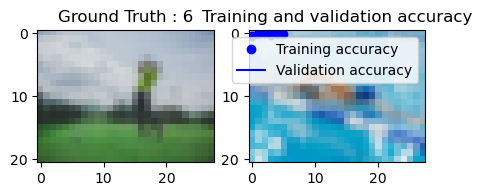

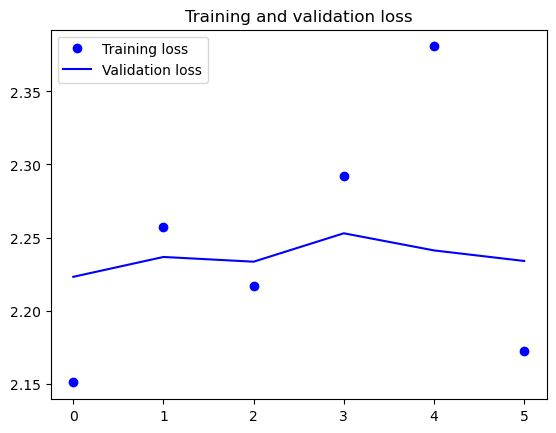

In [65]:
# ==================================================
# 10. GRÁFICAS DE ACCURACY Y LOSS
# ==================================================
accuracy = sport_train.history['accuracy']
val_accuracy = sport_train.history['val_accuracy']
loss = sport_train.history['loss']
val_loss = sport_train.history['val_loss']
epochs_range = range(len(accuracy))

plt.plot(epochs_range, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs_range, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs_range, loss, 'bo', label='Training loss')
plt.plot(epochs_range, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [66]:
# ==================================================
# 11. PREDICCIÓN SOBRE EL CONJUNTO DE PRUEBA
# ==================================================
predicted_classes2 = sport_model.predict(test_X)

predicted_classes = []
for predicted_sport in predicted_classes2:
    predicted_classes.append(predicted_sport.tolist().index(max(predicted_sport)))
predicted_classes = np.array(predicted_classes)

print(predicted_classes.shape, test_Y.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
(2,) (2,)


In [67]:
# ==================================================
# 12. ANÁLISIS DE RESULTADOS - PREDICCIONES CORRECTAS
# ==================================================
correct = np.where(predicted_classes == test_Y)[0]
print("Found %d correct labels" % len(correct))
for i, correct in enumerate(correct[0:9]):
    plt.subplot(3, 3, i+1)
    plt.imshow(test_X[correct].reshape(21, 28, 3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(deportes[predicted_classes[correct]], deportes[test_Y[correct]]))
    plt.tight_layout()

Found 0 correct labels


Found 2 incorrect labels


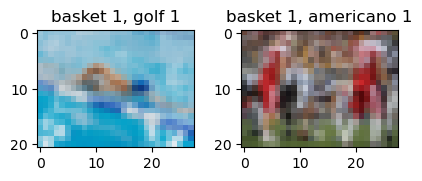

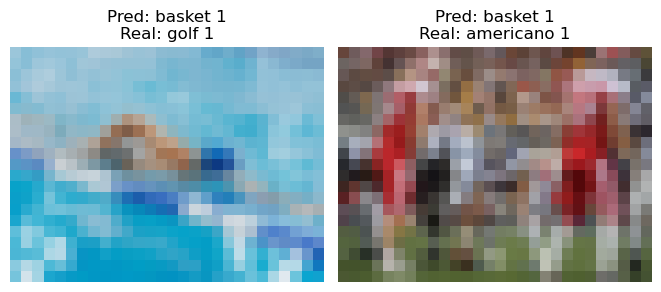

In [69]:
# ==================================================
# 13. ANÁLISIS DE RESULTADOS - PREDICCIONES INCORRECTAS
# ==================================================
incorrect = np.where(predicted_classes != test_Y)[0]
print("Found %d incorrect labels" % len(incorrect))

if len(incorrect) > 0:
    plt.figure(figsize=(10, 10))
    num_to_show = min(9, len(incorrect))  # Mostrar máximo 9
    
    for i in range(num_to_show):
        idx = incorrect[i]
        plt.subplot(3, 3, i+1)
        plt.imshow(test_X[idx].reshape(21, 28, 3), interpolation='none')
        plt.title("Pred: {}\nReal: {}".format(
            deportes[predicted_classes[idx]], 
            deportes[test_Y[idx]]
        ))
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("¡Perfecto! No hay predicciones incorrectas")

In [71]:
# ==================================================
# 14. REPORTE DE CLASIFICACIÓN
# ==================================================
# Obtener solo las clases presentes en el conjunto de prueba
classes_in_test = np.unique(test_Y)
target_names = [deportes[i] for i in classes_in_test]

print(classification_report(test_Y, predicted_classes, 
                          labels=classes_in_test, 
                          target_names=target_names,
                          zero_division=0))

              precision    recall  f1-score   support

 americano 1       0.00      0.00      0.00       1.0
      golf 1       0.00      0.00      0.00       1.0

   micro avg       0.00      0.00      0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Predicción: basket 1
Real: americano 1
¿Correcto?: NO 


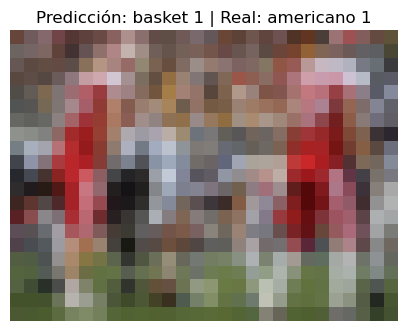

In [74]:
# ==================================================
# 15. PREDICCIÓN CON UNA IMAGEN DEL DATASET
# ==================================================
# Tomar una imagen aleatoria del conjunto de prueba
import random

idx = random.randint(0, len(test_X)-1)
test_image = test_X[idx:idx+1]  # Mantener dimensiones (1, 21, 28, 3)

predicted = sport_model.predict(test_image)
predicted_class = predicted[0].tolist().index(max(predicted[0]))
true_class = test_Y[idx]

print(f"Predicción: {deportes[predicted_class]}")
print(f"Real: {deportes[true_class]}")
print(f"¿Correcto?: {'SÍ ' if predicted_class == true_class else 'NO '}")

# Mostrar la imagen
plt.figure(figsize=(5, 5))
plt.imshow(test_image[0])
plt.title(f"Predicción: {deportes[predicted_class]} | Real: {deportes[true_class]}")
plt.axis('off')
plt.show()